# 04. Cellpose cell segmentation

In [ ]:
%%writefile constraints.txt
numpy<2.1,>=1.22

In [ ]:
!pip install -q -c constraints.txt "numpy<2.1,>=1.22"
!pip install -q -c constraints.txt cellpose
!pip install -q -c constraints.txt fastremap imagecodecs roifile fill-voids segment_anything ome-types tifffile natsort

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile

from pathlib import Path
from cellpose import models, core, io, utils

plt.style.use('dark_background')

io.logger_setup()
use_gpu = core.use_gpu()
print(f'GPU available: {use_gpu}')

In [ ]:
from pathlib import Path
import os

import numpy as np
import tifffile
import matplotlib.pyplot as plt
from skimage import exposure, segmentation
from skimage.color import label2rgb

cellpose_models_dir = Path('data/cellpose_models')
cellpose_models_dir.mkdir(parents=True, exist_ok=True)
Path('outputs').mkdir(exist_ok=True)
os.environ.setdefault('CELLPOSE_LOCAL_MODELS_PATH', str(cellpose_models_dir.resolve()))

hoechst = tifffile.imread('data/channels/00_Hoechst1.tif')
cellpose_image = hoechst

lo, hi = np.percentile(cellpose_image, [1, 99.8])
cellpose_input = exposure.rescale_intensity(
    cellpose_image,
    in_range=(lo, hi),
    out_range=(0, 1)
).astype('float32')

plt.imshow(cellpose_input, cmap='gray')
plt.title('Hoechst input for Cellpose-SAM')
plt.axis('off')

In [ ]:
model = models.CellposeModel(gpu=use_gpu, pretrained_model='cpsam')

masks, flows, styles = model.eval(
    cellpose_input,
    channel_axis=None,
    diameter=30,
    flow_threshold=0.4,
    cellprob_threshold=-1.0,
    min_size=20,
    batch_size=1,
    bsize=256,
)[:3]

In [ ]:
mask_path = Path('data/cellpose_hoechst_mask.tif')
tifffile.imwrite(mask_path, masks, compression='deflate')

print('Saved reusable mask:', mask_path)

In [13]:
masks = tifffile.imread('data/cellpose_hoechst_mask.tif')

In [15]:
boundaries = segmentation.find_boundaries(masks)
colored_masks = label2rgb(masks, bg_label=0)
overlay = np.dstack([cellpose_input, cellpose_input, cellpose_input])
overlay[boundaries] = [1, 0, 0]

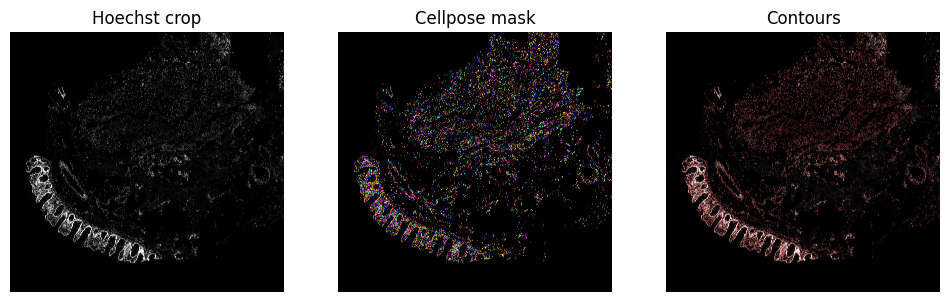

In [17]:

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(cellpose_input, cmap='gray')
ax[0].set_title('Hoechst crop')
ax[1].imshow(colored_masks)
ax[1].set_title('Cellpose mask')
ax[2].imshow(overlay)
ax[2].set_title('Contours')
for a in ax:
    a.axis('off')
plt.show()

In [ ]:
import tifffile
import numpy as np

overlay_uint8 = (overlay * 255).astype(np.uint8)
tifffile.imwrite('data/cellpose_contours_overlay.tif', overlay_uint8)

In [ ]:
from skimage.io import imsave
imsave(
    'outputs/cellpose_mask_colored.png',
    (colored_masks * 255).astype(np.uint8)
)

In [22]:
imsave(
    'outputs/cellpose_contours.png',
    (overlay * 255).astype(np.uint8)
)